# <span style='color:blue'> LAB 8: </span>
# <span style='color:blue'> GENERATIVE ADVERSARIAL NETWORKS </span>

In [146]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import pandas as pd
import seaborn as sns

In [147]:
# Seaborn plot styling
sns.set(style = 'white', font_scale = 2)

# MNIST Generation with Vanilla-GAN

## Prepare Data


In [ ]:
from torchvision.datasets import MNIST 
from torch.utils.data import DataLoader
from torchvision import transforms

# Define a transformation to convert the data into Tensors
train_transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))  # Normalize to [-1, 1] for Tanh
])

# Download the train and test MNIST data and transform it into Tensors
train_data = MNIST(root="./train.", train=True, download=True, transform=train_transforms)

## Define Model

In [ ]:
class Generator(torch.nn.Module):
    
    def __init__(self, batchsize, input_noise_dim):
        
        super(Generator, self).__init__()
        
        self.batchsize = batchsize  
        self.input_noise_dim = input_noise_dim  
        
        self.fc1 = torch.nn.Linear(input_noise_dim, 128)  
        self.LReLU = torch.nn.LeakyReLU()  # Leaky ReLU seemed to work best
        self.fc2 = torch.nn.Linear(128, 1 * 28 * 28) 
        self.output = torch.nn.Tanh()  

    def forward(self, x):
        
        layer1 = self.LReLU(self.fc1(x))  
        layer2 = self.output(self.fc2(layer1))  
        out = layer2.view(self.batchsize, 1, 28, 28)  # Reshape the output to match image dimensions
        
        return out

class Discriminator(torch.nn.Module):
    
    def __init__(self, batchsize):
        
        super(Discriminator, self).__init__()
        
        self.batchsize = batchsize  
        
        self.fc1 = torch.nn.Linear(1 * 28 * 28, 128)  
        self.LReLU = torch.nn.LeakyReLU()  
        self.dropout = torch.nn.Dropout(0.3)  # Dropout for discriminator only. Didn't seem much change
        self.fc2 = torch.nn.Linear(128, 1)  
        self.output = torch.nn.Sigmoid()  # Sigmoid 

    # Function for forward propagation
    def forward(self, x):
        
        flat = x.view(self.batchsize, -1)  
        layer1 = self.LReLU(self.fc1(flat))  
        layer1 = self.dropout(layer1)  
        out = self.output(self.fc2(layer1)) 
        
        return out.view(-1, 1).squeeze(1)  # Flatten the output and remove unnecessary dimension

## Define Hyperparameters

In [ ]:
torch.manual_seed(42)

# Define learning rates 
lr_generator = 0.0002
lr_discriminator = 0.0001
epochs = 100

batchsize = 128
input_noise_dim = 100

# How many times the discriminator is trained before the generator is updated
# Noticed no change with increased updates
disc_steps = 1

disc = Discriminator(batchsize)
gen = Generator(batchsize, input_noise_dim)

# Binary Cross Entropy (BCE) loss function
loss_func = torch.nn.BCELoss()

# Use standard GAN optimizer settings: betas=(0.5, 0.999) found online
optimizer_disc = torch.optim.Adam(disc.parameters(), lr=lr_discriminator, betas=(0.5, 0.999))
optimizer_gen = torch.optim.Adam(gen.parameters(), lr=lr_generator, betas=(0.5, 0.999))


device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
disc.to(device)
gen.to(device)

Generator(
  (fc1): Linear(in_features=100, out_features=128, bias=True)
  (LReLU): LeakyReLU(negative_slope=0.01)
  (fc2): Linear(in_features=128, out_features=784, bias=True)
  (output): Tanh()
)

## Identify Tracked Values

In [151]:
gen_train_loss_list = []
disc_train_loss_list = []

## Train Model

In [152]:
# Create DataLoader objects to efficiently load the training and test data in batches
train_loader = DataLoader(train_data, batch_size=batchsize, shuffle=False, drop_last=True)


In [ ]:
if torch.cuda.is_available():
    device = torch.device("cuda") 
else: 
    device = torch.device("cpu")

for epoch in range(epochs):
    
    print('Epoch {}/{}'.format(epoch + 1, epochs))
    running_loss_D = 0.0
    running_loss_G = 0.0
    
    for inputs, _ in train_loader:
        
        inputs = inputs.to(device)
        
        # label smoothing instead of 0 and 1
        real_label = torch.full((batchsize,), 0.9, dtype=inputs.dtype, device=device)
        fake_label = torch.full((batchsize,), 0.1, dtype=inputs.dtype, device=device)

        # Train Discriminator disc_steps times before each generator step ---------------------------------------------
        for _ in range(disc_steps):
            optimizer_disc.zero_grad()

            output_real = disc(inputs)
            D_real_loss = loss_func(output_real, real_label)
            D_real_loss.backward()

            noise = torch.randn(batchsize, input_noise_dim, device=device)
            fake = gen(noise)
            output_fake = disc(fake.detach())
            D_fake_loss = loss_func(output_fake, fake_label)
            D_fake_loss.backward()

            Disc_loss = D_real_loss + D_fake_loss
            optimizer_disc.step()

            running_loss_D += Disc_loss.item()
            disc_train_loss_list.append(Disc_loss.item())

        # Train Generator ------------------------------------------------------------------------------------------------------
        optimizer_gen.zero_grad()
        noise = torch.randn(batchsize, input_noise_dim, device=device)
        fake = gen(noise)
        output = disc(fake)

        Gen_loss = loss_func(output, real_label)
        Gen_loss.backward()
        optimizer_gen.step()

        running_loss_G += Gen_loss.item()
        gen_train_loss_list.append(Gen_loss.item())

    # Print the losses for the current epoch
    print("Discriminator Loss : {}".format(running_loss_D))
    print("Generator Loss : {}".format(running_loss_G))


Epoch 1/100
Discriminator Loss : 584.4077603816986
Generator Loss : 286.7866263985634
Epoch 2/100
Discriminator Loss : 569.6851494312286
Generator Loss : 318.6580477952957
Epoch 3/100
Discriminator Loss : 586.5126632452011
Generator Loss : 325.7804619669914
Epoch 4/100
Discriminator Loss : 579.3134698867798
Generator Loss : 343.24608284235
Epoch 5/100
Discriminator Loss : 571.4089769124985
Generator Loss : 361.6188341975212
Epoch 6/100
Discriminator Loss : 568.214374423027
Generator Loss : 373.08202570676804
Epoch 7/100
Discriminator Loss : 559.2229299545288
Generator Loss : 387.5076522231102
Epoch 8/100
Discriminator Loss : 562.165777683258
Generator Loss : 390.7799335718155
Epoch 9/100
Discriminator Loss : 548.856785774231
Generator Loss : 408.25879180431366
Epoch 10/100
Discriminator Loss : 539.9994742870331
Generator Loss : 422.39359921216965
Epoch 11/100
Discriminator Loss : 531.8141193389893
Generator Loss : 435.2095052599907
Epoch 12/100
Discriminator Loss : 526.3896080255508
Ge

## Visualize & Evaluate Model

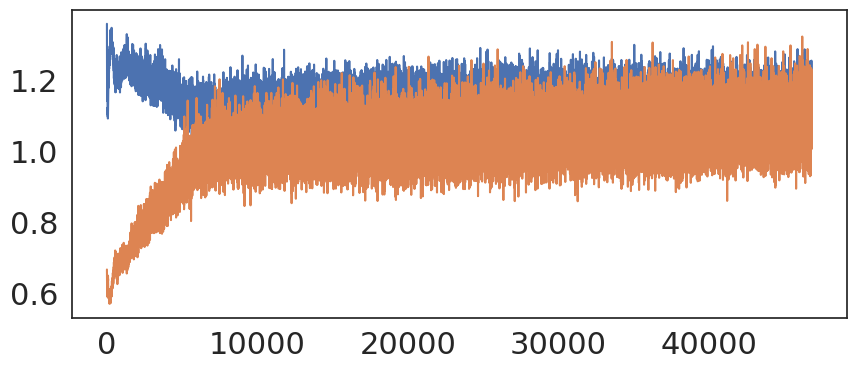

In [154]:
import matplotlib.pyplot as plt

plt.figure(figsize = (10, 4))

plt.plot(disc_train_loss_list)
plt.plot(gen_train_loss_list)

In [ ]:
def show_image(img):
    # Convert the image from a tensor to a NumPy array
    npimg = img.numpy()
    # Denormalize for display
    npimg = (npimg + 1) / 2.0
    # Clip values to [0, 1] range to ensure valid display
    npimg = np.clip(npimg, 0, 1)
    # Transpose the NumPy array to the correct format for displaying
    plt.imshow(np.transpose(npimg, (1, 2, 0)))

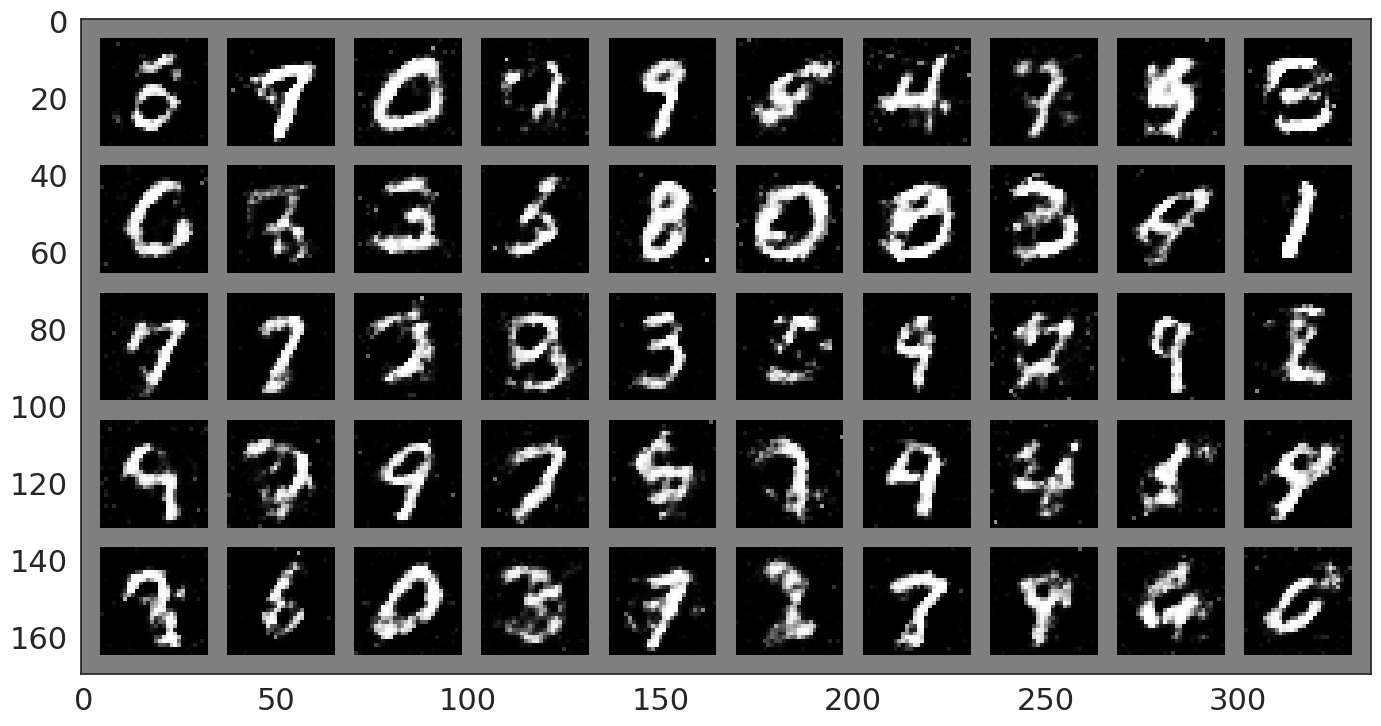

In [ ]:
import torchvision

random_noise = torch.randn(128, input_noise_dim, device=device)

with torch.no_grad():
    
    fake = gen(random_noise)
    fake = fake.cpu()  # Move the generated fake images to the CPU for displaying
    
    fig, ax = plt.subplots(figsize=(20, 8.5))
    
    show_image(torchvision.utils.make_grid(fake[0:50], 10, 5))
    
    plt.show()


### Briefly describe your experience of using DCGAN vs Vanilla-GAN

# Notes

- The initial descriminator network did a terrible job

- Loss tell me very little so each change was more sujbect than previous models

- Adding multiple discriminator updates before generator seemed to make things worse

- Data normalization did the most because it made it stable for longer trainings

- Added Label smoothing instead of 1,0. Seemed to have some positive impact

- Since the output was so subjective, I really should have exported the generated images of each run for later comparison

  

There were lots of advanced suggestions online, but they seemed a bit too ambitious to learn and implement here.

- Fancy seeding for better reproducibility

- Data shuffling

- Flexible update scheduling